# MC_DELAY_PER_TRAIN Calibratie

Dit notebook onderzoekt welke waarde voor `MC_DELAY_PER_TRAIN` de beste balans geeft
tussen **solver effort** (`n_rescheduled`) en **performantie** (`TED_combined`).

**Wat meten we?**
- Een lage `MC_DELAY_PER_TRAIN` → threshold ligt laag → trigger vuurt snel → veel reschedules, lage delay
- Een hoge `MC_DELAY_PER_TRAIN` → threshold ligt hoog → trigger vuurt zelden → weinig reschedules, hogere delay
- We zoeken het knikpunt: waar stijgt de delay zonder dat de solver significant minder werkt?

**Aanpak:** meerdere seeds per waarde voor robuuste schatting.

In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path.cwd().parent))

import config.settings as settings
from run_simulation import run_simulation
from utils.metrics import compute_metrics

## Configuratie

In [2]:
# --- Te testen waarden voor MC_DELAY_PER_TRAIN (seconden, gemiddelde per trein) ---
MC_VALUES = [ 40, 90, 120, 180, 240,300]

# --- Seeds per waarde: meer seeds = betrouwbaardere schatting, maar trager ---
SEEDS = [1,2,3,4,5,6,7,8,9,10]

# --- Vaste simulatieparameters (zelfde als je hoofdexperiment) ---
SIM_PARAMS = dict(
    n_freight            = 182,
    trigger_strategy     = "event_driven", #"event_driven",   # puur event-driven: MC_DELAY_PER_TRAIN heeft hier maximale impact
    event_driven_freq    = 900,
    controller_freq      = 450,
    threshold_confidence = 0.6,
    objective_strategy   = "static",
    weight_passenger     = 1,
    weight_freight       = 1,
    dynamic_threshold    = 120,
)

print(f"Grid: {len(MC_VALUES)} waarden × {len(SEEDS)} seeds = {len(MC_VALUES)*len(SEEDS)} runs")

Grid: 6 waarden × 10 seeds = 60 runs


## Sweep uitvoeren

We overschrijven `config.settings.MC_DELAY_PER_TRAIN` tijdelijk per run
en herladen de trigger-module zodat de nieuwe waarde opgepikt wordt.

In [3]:
import gc
import io
import contextlib

rows = []

for mc_val in MC_VALUES:
    print(f"\n{'='*60}")
    print(f"MC_DELAY_PER_TRAIN = {mc_val}s")
    print(f"{'='*60}")

    for seed in SEEDS:
        print(f"  seed={seed} ... ", end="", flush=True)

        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            state, df, meta, _ ,_= run_simulation(
                **SIM_PARAMS,
                mc_delay_per_train = mc_val,
                seed               = seed,
                save               = False,
            )
        if meta["deadlock_detected"]:
            print(f"  seed={seed} mc={mc_val} → DEADLOCK (uitgesloten)")
            continue

        metrics = compute_metrics(df)
        ctrl    = meta.get("controller_summary", {})

        rows.append({
            "mc_delay_per_train" : mc_val,
            "seed"               : seed,
            "TED_combined"       : metrics.get("TED_combined"),
            "TED_passenger"      : metrics.get("TED_passenger"),
            "TED_freight"        : metrics.get("TED_freight"),
            "n_rescheduled"      : ctrl.get("n_rescheduled", 0),
            "n_evaluated"        : ctrl.get("n_evaluated", 0),
            "n_skipped"          : ctrl.get("n_skipped", 0),
            "n_fcfs_fallback"    : ctrl.get("n_fcfs_fallback", 0),
            "total_solver_time"  : ctrl.get("total_solver_runtime_s", 0.0),
        })

        del state, df
        gc.collect()

        print(f"TED={metrics.get('TED_combined', float('nan')):.1f}s  "
              f"n_rescheduled={ctrl.get('n_rescheduled', 0)}  "
              f"n_evaluated={ctrl.get('n_evaluated', 0)}")

raw = pd.DataFrame(rows)
print(f"\nKlaar — {len(raw)} runs")
raw



MC_DELAY_PER_TRAIN = 40s
  seed=1 ... 
Interrupt request received
  seed=1 mc=40 → DEADLOCK (uitgesloten)
  seed=2 ... TED=72896.8s  n_rescheduled=84  n_evaluated=105
  seed=3 ... TED=57706.3s  n_rescheduled=83  n_evaluated=104
  seed=4 ... TED=67515.1s  n_rescheduled=83  n_evaluated=104
  seed=5 ... TED=58742.2s  n_rescheduled=84  n_evaluated=103
  seed=6 ... TED=55841.0s  n_rescheduled=86  n_evaluated=105
  seed=7 ... TED=58803.1s  n_rescheduled=83  n_evaluated=104
  seed=8 ... TED=69299.6s  n_rescheduled=85  n_evaluated=103
  seed=9 ... TED=58107.7s  n_rescheduled=82  n_evaluated=105
  seed=10 ... TED=64434.4s  n_rescheduled=84  n_evaluated=102

MC_DELAY_PER_TRAIN = 90s
  seed=1 ... TED=61553.5s  n_rescheduled=71  n_evaluated=115
  seed=2 ... TED=58421.8s  n_rescheduled=75  n_evaluated=113
  seed=3 ... TED=59308.9s  n_rescheduled=69  n_evaluated=118
  seed=4 ... TED=60304.1s  n_rescheduled=72  n_evaluated=114
  seed=5 ... TED=67221.4s  n_rescheduled=70  n_evaluated=115
  seed=6 ...

,mc_delay_per_train,seed,TED_combined,TED_passenger,TED_freight,n_rescheduled,n_evaluated,n_skipped,n_fcfs_fallback,total_solver_time
0,40,2,72896.8,52357.9,20538.9,84,105,10945,0,18.292774
1,40,3,57706.3,39789.1,17917.2,83,104,10925,0,12.918123
2,40,4,67515.1,43879.5,23635.6,83,104,10959,0,14.927587
3,40,5,58742.2,41990.0,16752.2,84,103,10942,0,12.183235
4,40,6,55841.0,40216.8,15624.2,86,105,10914,0,11.516498
5,40,7,58803.1,40835.6,17967.5,83,104,10930,0,11.822019
6,40,8,69299.6,40524.4,28775.2,85,103,10937,0,12.071930
7,40,9,58107.7,43302.9,14804.8,82,105,10931,0,11.588988
8,40,10,64434.4,42721.8,21712.6,84,102,10948,0,13.130978
9,90,1,61553.5,43563.3,17990.2,71,115,10974,0,10.608787


## Aggregatie per MC-waarde

In [2]:
print(raw.columns)

NameError: name 'raw' is not defined

In [4]:
agg = (
    raw
    .groupby("mc_delay_per_train")
    .agg(
        TED_combined_mean      = ("TED_combined",   "mean"),
        TED_combined_std       = ("TED_combined",   "std"),
        TED_passenger_mean     = ("TED_passenger",  "mean"),
        TED_passenger_std      = ("TED_passenger",  "std"),
        TED_freight_mean       = ("TED_freight",    "mean"),
        TED_freight_std        = ("TED_freight",    "std"),
        n_rescheduled_mean     = ("n_rescheduled",  "mean"),
        n_rescheduled_std      = ("n_rescheduled",  "std"),
        n_evaluated_mean       = ("n_evaluated",    "mean"),
        total_solver_time_mean = ("total_solver_time", "mean"),
        total_solver_time_std  = ("total_solver_time", "std"),
    )
    .reset_index()
)
agg = agg.round(2)
agg


,mc_delay_per_train,TED_combined_mean,TED_combined_std,TED_passenger_mean,TED_passenger_std,TED_freight_mean,TED_freight_std,n_rescheduled_mean,n_rescheduled_std,n_evaluated_mean,total_solver_time_mean,total_solver_time_std
0,40,62594.02,6098.60,42846.44,3843.67,19747.58,4444.47,83.78,1.20,103.89,13.16,2.20
1,90,59570.27,3763.48,41502.58,1794.19,18067.69,2953.80,72.50,2.17,114.20,11.07,0.73
2,120,59420.14,4276.85,41441.02,2253.26,17979.12,2585.93,61.67,3.67,124.00,9.84,1.32
3,180,60883.55,3256.75,43062.75,2195.88,17820.80,1818.02,42.90,3.48,142.70,7.07,1.57
4,240,62038.68,11682.54,42602.36,3558.65,19436.32,8251.12,24.67,3.16,160.33,10.90,22.78
5,300,59835.10,3566.78,42662.30,1504.17,17172.80,2613.97,11.80,3.36,172.70,1.76,0.57


## Plot: TED_combined en n_rescheduled vs MC_DELAY_PER_TRAIN

Twee assen: links de delay (lager = beter), rechts het aantal reschedules (lager = goedkoper).  
Het optimum ligt waar de delay laag blijft maar de reschedules significant dalen.

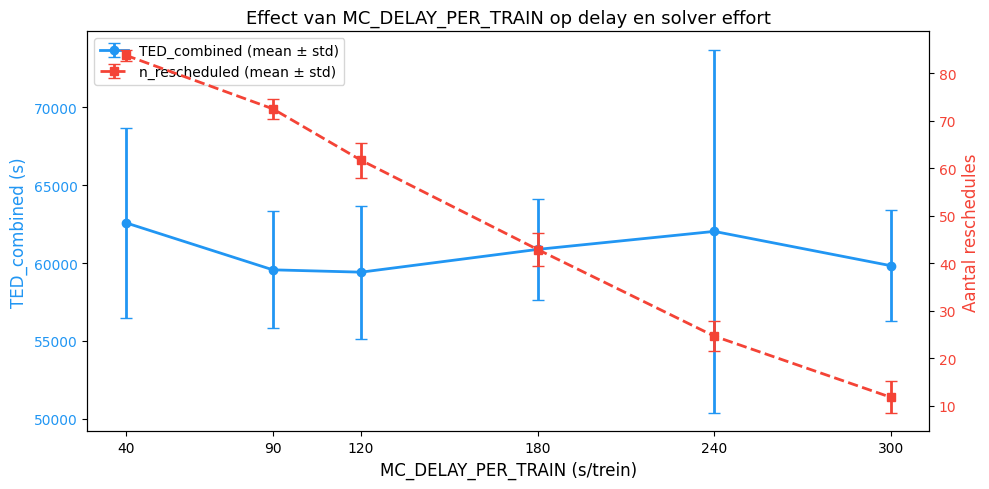

Figuur opgeslagen als mc_threshold_sweep.png


In [5]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color_ted   = "#2196F3"
color_reschedule = "#F44336"

x = agg["mc_delay_per_train"]

# --- TED_combined (links) ---
ax1.errorbar(
    x, agg["TED_combined_mean"], yerr=agg["TED_combined_std"],
    color=color_ted, marker="o", linewidth=2, capsize=4, label="TED_combined (mean ± std)"
)
ax1.set_xlabel("MC_DELAY_PER_TRAIN (s/trein)", fontsize=12)
ax1.set_ylabel("TED_combined (s)", color=color_ted, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_ted)
ax1.set_xticks(x)

# --- n_rescheduled (rechts) ---
ax2 = ax1.twinx()
ax2.errorbar(
    x, agg["n_rescheduled_mean"], yerr=agg["n_rescheduled_std"],
    color=color_reschedule, marker="s", linewidth=2, linestyle="--",
    capsize=4, label="n_rescheduled (mean ± std)"
)
ax2.set_ylabel("Aantal reschedules", color=color_reschedule, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_reschedule)

# Gecombineerde legenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Effect van MC_DELAY_PER_TRAIN op delay en solver effort", fontsize=13)
plt.tight_layout()
plt.savefig("mc_threshold_sweep.png", dpi=150)
plt.show()
print("Figuur opgeslagen als mc_threshold_sweep.png")

## Plot: Pareto-front  (TED_combined vs n_rescheduled)

Elke punt is één MC-waarde (gemiddeld over seeds).  
Linksonder = ideaal. Punten op de Pareto-rand zijn de beste trade-offs.

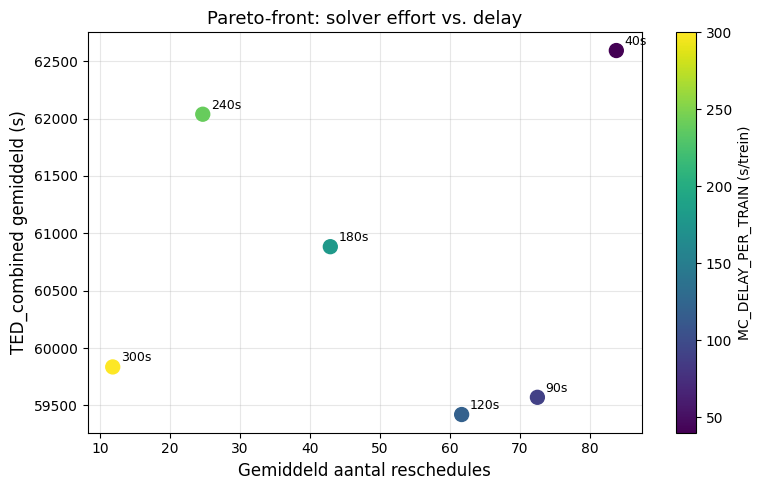

Figuur opgeslagen als mc_threshold_pareto.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    agg["n_rescheduled_mean"],
    agg["TED_combined_mean"],
    c=agg["mc_delay_per_train"],
    cmap="viridis",
    s=100,
    zorder=3,
)
plt.colorbar(scatter, ax=ax, label="MC_DELAY_PER_TRAIN (s/trein)")

# Label elk punt
for _, row in agg.iterrows():
    ax.annotate(
        f"{int(row['mc_delay_per_train'])}s",
        xy=(row["n_rescheduled_mean"], row["TED_combined_mean"]),
        xytext=(6, 4), textcoords="offset points", fontsize=9,
    )

ax.set_xlabel("Gemiddeld aantal reschedules", fontsize=12)
ax.set_ylabel("TED_combined gemiddeld (s)", fontsize=12)
ax.set_title("Pareto-front: solver effort vs. delay", fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mc_threshold_pareto.png", dpi=150)
plt.show()
print("Figuur opgeslagen als mc_threshold_pareto.png")

## Numerieke samenvatting

Relatieve verandering t.o.v. de laagste MC-waarde (meest agressieve trigger).

In [7]:
baseline_ted  = agg["TED_combined_mean"].iloc[0]
baseline_resc = agg["n_rescheduled_mean"].iloc[0]

summary = agg[["mc_delay_per_train", "TED_combined_mean", "TED_combined_std",
               "n_rescheduled_mean", "n_rescheduled_std", "total_solver_time_mean"]].copy()

summary["TED_rel_%"]       = ((summary["TED_combined_mean"]  - baseline_ted)  / baseline_ted  * 100).round(1)
summary["reschedule_rel_%"] = ((summary["n_rescheduled_mean"] - baseline_resc) / baseline_resc * 100).round(1)

summary.columns = [
    "MC_DELAY_PER_TRAIN", "TED_mean", "TED_std",
    "n_rescheduled_mean", "n_rescheduled_std", "solver_time_mean",
    "ΔTED%", "Δreschedule%"
]
summary

,MC_DELAY_PER_TRAIN,TED_mean,TED_std,n_rescheduled_mean,n_rescheduled_std,solver_time_mean,ΔTED%,Δreschedule%
0,40,62594.02,6098.60,83.78,1.20,13.16,0.0,0.0
1,90,59570.27,3763.48,72.50,2.17,11.07,-4.8,-13.5
2,120,59420.14,4276.85,61.67,3.67,9.84,-5.1,-26.4
3,180,60883.55,3256.75,42.90,3.48,7.07,-2.7,-48.8
4,240,62038.68,11682.54,24.67,3.16,10.90,-0.9,-70.6
5,300,59835.10,3566.78,11.80,3.36,1.76,-4.4,-85.9


In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

efficiency = raw.copy()

# Correcte reschedule rate: n_rescheduled / n_evaluated (MC-evaluaties na beide frequentiechecks)
efficiency['reschedule_rate_%'] = (
    efficiency['n_rescheduled']
    / efficiency['n_evaluated'].replace(0, float('nan')) * 100
)

eff_agg = (
    efficiency
    .groupby('mc_delay_per_train')
    .agg(
        reschedule_rate_mean = ('reschedule_rate_%', 'mean'),
        reschedule_rate_std  = ('reschedule_rate_%', 'std'),
        n_rescheduled_mean   = ('n_rescheduled',     'mean'),
        n_evaluated_mean     = ('n_evaluated',        'mean'),
        n_skipped_mean       = ('n_skipped',          'mean'),
        n_fcfs_mean          = ('n_fcfs_fallback',    'mean'),
        TED_mean             = ('TED_combined',       'mean'),
    )
    .reset_index()
)

print("Reschedule efficiency per MC_DELAY_PER_TRAIN waarde:")
print(eff_agg[[
    'mc_delay_per_train', 'n_evaluated_mean', 'n_rescheduled_mean',
    'n_skipped_mean', 'n_fcfs_mean', 'reschedule_rate_mean', 'TED_mean'
]].round(2).to_string(index=False))

# ── Interactieve plot ─────────────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        '% MC-evaluaties → Reschedule (efficiëntie)',
        'TED vs Reschedule Rate',
    ],
    horizontal_spacing=0.14,
)

mc_vals = eff_agg['mc_delay_per_train'].tolist()

def hover_eff(row):
    return (
        f"<b>MC={row['mc_delay_per_train']}s</b><br>"
        f"Reschedule rate: {row['reschedule_rate_mean']:.1f}% "
        f"(±{row['reschedule_rate_std']:.1f}%)<br>"
        f"MC-evaluaties:   {row['n_evaluated_mean']:.1f}<br>"
        f"→ rescheduled:   {row['n_rescheduled_mean']:.1f}<br>"
        f"→ skipped:       {row['n_skipped_mean']:.1f}<br>"
        f"→ fcfs fallback: {row['n_fcfs_mean']:.1f}<br>"
        f"TED mean:        {row['TED_mean']:.0f}s"
    )

hover_texts = eff_agg.apply(hover_eff, axis=1).tolist()

fig.add_trace(go.Scatter(
    x=mc_vals,
    y=eff_agg['reschedule_rate_mean'],
    error_y=dict(type='data', array=eff_agg['reschedule_rate_std'].tolist(), visible=True),
    mode='lines+markers',
    marker=dict(size=9, color='#2196F3'),
    line=dict(width=2),
    name='Reschedule rate %',
    hovertemplate='%{customdata}<extra></extra>',
    customdata=hover_texts,
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=eff_agg['reschedule_rate_mean'],
    y=eff_agg['TED_mean'],
    mode='markers+text',
    marker=dict(
        size=10,
        color=mc_vals,
        colorscale='Viridis',
        colorbar=dict(title='MC (s)', x=1.02),
        showscale=True,
    ),
    text=[f"{v}s" for v in mc_vals],
    textposition='top center',
    name='TED vs rate',
    hovertemplate='%{customdata}<extra></extra>',
    customdata=hover_texts,
), row=1, col=2)

fig.update_xaxes(title_text='MC_DELAY_PER_TRAIN (s)', row=1, col=1)
fig.update_yaxes(title_text='% MC-evaluaties → reschedule', row=1, col=1)
fig.update_xaxes(title_text='Reschedule rate (%)', row=1, col=2)
fig.update_yaxes(title_text='TED combined mean (s)', row=1, col=2)
fig.update_layout(title_text='MC Threshold — Reschedule Efficiency Check')
fig.show()


Reschedule efficiency per MC_DELAY_PER_TRAIN waarde:
 mc_delay_per_train  n_evaluated_mean  n_rescheduled_mean  n_skipped_mean  n_fcfs_mean  reschedule_rate_mean  TED_mean
                 40            103.89               83.78        10936.78         0.00                 80.65  62594.02
                 90            114.20               72.50        10942.50         0.00                 63.53  59570.27
                120            124.00               61.67        10951.33         0.00                 49.85  59420.14
                180            142.70               42.90        10979.20         0.00                 30.15  60883.55
                240            160.33               24.67        10983.33         0.11                 15.43  62038.68
                300            172.70               11.80        11005.00         0.00                  6.87  59835.10


---
## Verificatie gekozen waarde

Hieronder bevestigen we dat de gekozen `MC_DELAY_PER_TRAIN` zich in een zinvol bereik bevindt:
- **Trigger rate** (% van evaluaties waar MC vuurt): verwacht 30–70%
- **Confidence-verdeling**: histogram van ruwe MC-confidence scores over alle seeds
- **Drempelberekening**: gemiddelde `performance_threshold` vs gemiddelde systeemvertraging

Pas `CHOSEN_MC` aan naar de waarde die je wil verificeren.

In [9]:
# ── Kies de te verificeren waarde ─────────────────────────────────────────────
CHOSEN_MC = 180  # <-- aanpassen naar gekozen MC_DELAY_PER_TRAIN

# ── Filter raw data op gekozen waarde ─────────────────────────────────────────
chosen = raw[raw["mc_delay_per_train"] == CHOSEN_MC].copy()
if chosen.empty:
    raise ValueError(f"MC_DELAY_PER_TRAIN={CHOSEN_MC} niet gevonden in raw data. "
                     f"Beschikbare waarden: {sorted(raw['mc_delay_per_train'].unique())}")

n_seeds = len(chosen)

# Correcte reschedule rate: n_rescheduled / n_evaluated
chosen["trigger_rate_%"] = (
    chosen["n_rescheduled"]
    / chosen["n_evaluated"].replace(0, float("nan"))
    * 100
)

# ── Samenvatting ──────────────────────────────────────────────────────────────
print(f"=" * 55)
print(f"Verificatie MC_DELAY_PER_TRAIN = {CHOSEN_MC}s")
print(f"=" * 55)
print(f"Seeds: {n_seeds}")
print()
print(f"  Trigger rate (% MC-evaluaties → reschedule):")
print(f"    mean = {chosen['trigger_rate_%'].mean():.1f}%")
print(f"    std  = {chosen['trigger_rate_%'].std():.1f}%")
print(f"    min  = {chosen['trigger_rate_%'].min():.1f}%  "
      f"max = {chosen['trigger_rate_%'].max():.1f}%")
print()
print(f"  n_evaluated (MC draaide effectief) per run:")
print(f"    mean = {chosen['n_evaluated'].mean():.1f}")
print()
print(f"  n_rescheduled per run:")
print(f"    mean = {chosen['n_rescheduled'].mean():.1f}")
print(f"    std  = {chosen['n_rescheduled'].std():.1f}")
print()
print(f"  TED_combined per run:")
print(f"    mean = {chosen['TED_combined'].mean():.0f}s")
print(f"    std  = {chosen['TED_combined'].std():.0f}s")
print()

# ── Beoordeling ───────────────────────────────────────────────────────────────
tr_mean = chosen["trigger_rate_%"].mean()
if tr_mean < 10:
    label = "⚠️  ZEER LAAG — threshold te hoog, trigger vuurt zelden"
elif tr_mean < 30:
    label = "🔶  LAAG — trigger relatief inactief"
elif tr_mean <= 70:
    label = "✅  OK — trigger in gewenst bereik"
elif tr_mean <= 90:
    label = "🔶  HOOG — trigger relatief actief"
else:
    label = "⚠️  ZEER HOOG — threshold te laag, trigger vuurt bijna altijd"
print(f"  Beoordeling: {label}")

# ── Vergelijking met referentiewaarden uit de sweep ──────────────────────────
print()
print("  Trigger rate over alle MC-waarden (ter vergelijking):")
ref = raw.copy()
ref["trigger_rate_%"] = (
    ref["n_rescheduled"]
    / ref["n_evaluated"].replace(0, float("nan")) * 100
)
ref_agg = ref.groupby("mc_delay_per_train")["trigger_rate_%"].mean().reset_index()
ref_agg.columns = ["MC_DELAY_PER_TRAIN", "trigger_rate_mean_%"]
ref_agg["trigger_rate_mean_%"] = ref_agg["trigger_rate_mean_%"].round(1)
ref_agg["→ gekozen"] = ref_agg["MC_DELAY_PER_TRAIN"].apply(
    lambda v: "◀ GEKOZEN" if v == CHOSEN_MC else ""
)
print(ref_agg.to_string(index=False))


Verificatie MC_DELAY_PER_TRAIN = 180s
Seeds: 10

  Trigger rate (% MC-evaluaties → reschedule):
    mean = 30.2%
    std  = 3.3%
    min  = 25.3%  max = 35.0%

  n_evaluated (MC draaide effectief) per run:
    mean = 142.7

  n_rescheduled per run:
    mean = 42.9
    std  = 3.5

  TED_combined per run:
    mean = 60884s
    std  = 3257s

  Beoordeling: ✅  OK — trigger in gewenst bereik

  Trigger rate over alle MC-waarden (ter vergelijking):
 MC_DELAY_PER_TRAIN  trigger_rate_mean_% → gekozen
                 40                 80.7          
                 90                 63.5          
                120                 49.8          
                180                 30.2 ◀ GEKOZEN
                240                 15.4          
                300                  6.9          


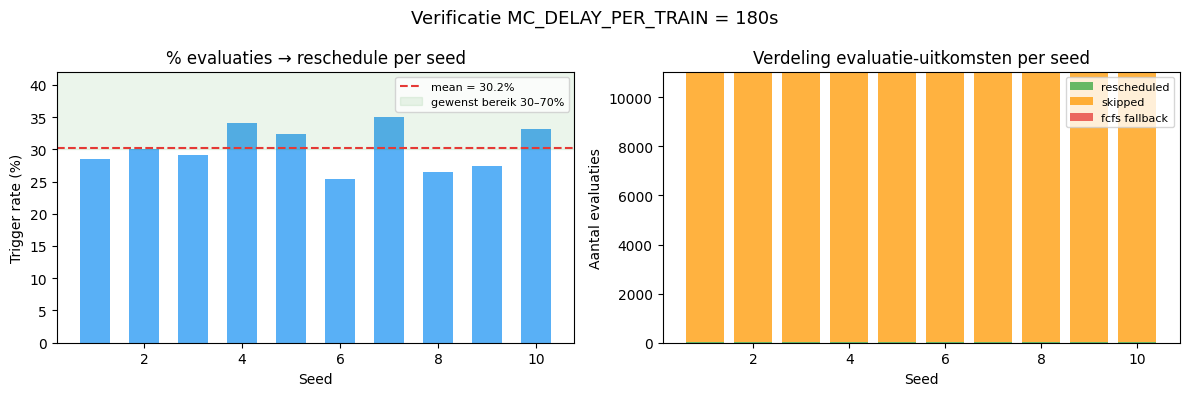

In [10]:
# ── Plot: trigger rate per seed voor gekozen waarde ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Verificatie MC_DELAY_PER_TRAIN = {CHOSEN_MC}s", fontsize=13)

# Links: trigger rate per seed
ax = axes[0]
ax.bar(
    chosen["seed"], chosen["trigger_rate_%"],
    color="#2196F3", alpha=0.75, width=0.6
)
ax.axhline(chosen["trigger_rate_%"].mean(), color="#E53935", ls="--", lw=1.5,
           label=f"mean = {chosen['trigger_rate_%'].mean():.1f}%")
ax.axhspan(30, 70, alpha=0.08, color="green", label="gewenst bereik 30–70%")
ax.set_xlabel("Seed")
ax.set_ylabel("Trigger rate (%)")
ax.set_title("% evaluaties → reschedule per seed")
ax.legend(fontsize=8)
ax.set_ylim(0, max(chosen["trigger_rate_%"].max() * 1.2, 5))

# Rechts: stacked bar (rescheduled / skipped / fcfs) per seed
ax2 = axes[1]
seeds = chosen["seed"].tolist()
ax2.bar(seeds, chosen["n_rescheduled"],   label="rescheduled",   color="#4CAF50", alpha=0.85)
ax2.bar(seeds, chosen["n_skipped"],       label="skipped",       color="#FF9800", alpha=0.75,
        bottom=chosen["n_rescheduled"])
ax2.bar(seeds, chosen["n_fcfs_fallback"], label="fcfs fallback", color="#E53935", alpha=0.75,
        bottom=chosen["n_rescheduled"] + chosen["n_skipped"])
ax2.set_xlabel("Seed")
ax2.set_ylabel("Aantal evaluaties")
ax2.set_title("Verdeling evaluatie-uitkomsten per seed")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Sweep: trigger rate bij verschillende configuraties

Nu testen we hoe `threshold_confidence` en `MC_DELAY_PER_TRAIN` samen de trigger rate beïnvloeden.

**Wat meten we?**
- `triggered_%`  — % van MC-evaluaties waar confidence ≥ threshold → solver wordt aangeroepen
- `not_triggered_%` — % waarbij confidence < threshold → trigger vuurt niet

We sweepen over een grid van `(mc_delay_per_train, threshold_confidence)` combinaties,
elk met meerdere seeds. Doel: een heatmap die toont welke combinaties in het gewenste bereik vallen.

In [11]:
# ── Grid configuratie ─────────────────────────────────────────────────────────
# mc_delay_per_train waarden: subset van je sweep (of volledig grid)
CONF_SWEEP_MC_VALUES    = [ 180]
CONF_SWEEP_CONF_VALUES  = [ 0.4, 0.6, 0.8]
CONF_SWEEP_SEEDS        = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,13,14,15,16,17,18,19,20]  

# Vaste simulatieparameters (zelfde als boven)
CONF_SIM_PARAMS = SIM_PARAMS.copy()
# threshold_confidence wordt per iteratie overschreven

print(f"Grid: {len(CONF_SWEEP_MC_VALUES)} MC-waarden "
      f"× {len(CONF_SWEEP_CONF_VALUES)} confidence-drempels "
      f"× {len(CONF_SWEEP_SEEDS)} seeds "
      f"= {len(CONF_SWEEP_MC_VALUES) * len(CONF_SWEEP_CONF_VALUES) * len(CONF_SWEEP_SEEDS)} runs")

Grid: 1 MC-waarden × 3 confidence-drempels × 20 seeds = 60 runs


In [ ]:
import gc
import io
import contextlib
import importlib

conf_rows = []

for mc_val in CONF_SWEEP_MC_VALUES:
    for conf_val in CONF_SWEEP_CONF_VALUES:
        print(f"MC={mc_val:>4}s  conf={conf_val:.1f}", end="", flush=True)

        sim_params = CONF_SIM_PARAMS.copy()
        sim_params["threshold_confidence"] = conf_val

        seed_results = []
        for seed in CONF_SWEEP_SEEDS:
            try:
                buf = io.StringIO()
                with contextlib.redirect_stdout(buf):
                    state, df, meta, _ = run_simulation(
                        **sim_params,
                        mc_delay_per_train=mc_val,
                        seed=seed,
                        save=False,
                    )

                if meta.get("deadlock_detected"):
                    print(f"  ✗ seed={seed} → DEADLOCK (uitgesloten)")
                    del state, df
                    gc.collect()
                    continue

                ctrl    = meta.get("controller_summary", {})
                metrics = compute_metrics(df)

                n_resc      = ctrl.get("n_rescheduled",  0)
                n_evaluated = ctrl.get("n_evaluated",    0)
                n_skip      = ctrl.get("n_skipped",       0)
                n_fcfs      = ctrl.get("n_fcfs_fallback", 0)

                # Correcte trigger rate: n_rescheduled / n_evaluated
                trigger_rate = (
                    round(n_resc / n_evaluated * 100, 2)
                    if n_evaluated else None
                )

                seed_results.append({
                    "mc_delay_per_train":   mc_val,
                    "threshold_confidence": conf_val,
                    "seed":                seed,
                    "n_rescheduled":       n_resc,
                    "n_evaluated":         n_evaluated,
                    "n_skipped":           n_skip,
                    "n_fcfs_fallback":     n_fcfs,
                    "triggered_%":         trigger_rate,
                    "TED_combined":        metrics.get("TED_combined"),
                    "total_solver_time":   ctrl.get("total_solver_runtime_s", 0.0),
                })

                del state, df
                gc.collect()

            except Exception as e:
                print(f"\n  ✗ seed={seed} mc={mc_val} conf={conf_val} → {type(e).__name__}: {e}")

        n_ok = len(seed_results)
        if n_ok > 0:
            tr_m = sum(r["triggered_%"] for r in seed_results if r["triggered_%"] is not None) / n_ok
        else:
            tr_m = float("nan")
        print(f"  → {n_ok}/{len(CONF_SWEEP_SEEDS)} seeds OK   triggered_mean={tr_m:.1f}%")
        conf_rows.extend(seed_results)

conf_raw = pd.DataFrame(conf_rows)
print(f"\nKlaar — {len(conf_raw)} runs")
conf_raw.head()


MC= 180s  conf=0.4
  ✗ seed=1 mc=180 conf=0.4 → ValueError: too many values to unpack (expected 4)

Interrupt request received


In [ ]:
# ── Aggregeer over seeds: mean triggered_% per (mc, conf) combinatie ─────────
conf_agg = (
    conf_raw
    .groupby(["mc_delay_per_train", "threshold_confidence"])
    .agg(
        triggered_mean     = ("triggered_%",   "mean"),
        triggered_std      = ("triggered_%",   "std"),
        TED_mean           = ("TED_combined",  "mean"),
        TED_std            = ("TED_combined",  "std"),
        n_rescheduled_mean = ("n_rescheduled", "mean"),
        n_evaluated_mean   = ("n_evaluated",   "mean"),
        n_seeds            = ("seed",          "count"),
    )
    .reset_index()
)
conf_agg = conf_agg.round(2)

print("Trigger rate (% MC-evaluaties → reschedule) per configuratie:")
pivot_triggered = conf_agg.pivot(
    index="mc_delay_per_train",
    columns="threshold_confidence",
    values="triggered_mean",
).round(1)
print(pivot_triggered.to_string())
print()
print("TED_combined mean per configuratie:")
pivot_ted = conf_agg.pivot(
    index="mc_delay_per_train",
    columns="threshold_confidence",
    values="TED_mean",
).round(0)
print(pivot_ted.to_string())


Trigger rate (% MC-evaluaties → reschedule) per configuratie:
threshold_confidence   0.4   0.6   0.8
mc_delay_per_train                    
180                   38.2  32.1  26.5

TED_combined mean per configuratie:
threshold_confidence      0.4      0.6      0.8
mc_delay_per_train                             
180                   55669.0  56062.0  58539.0


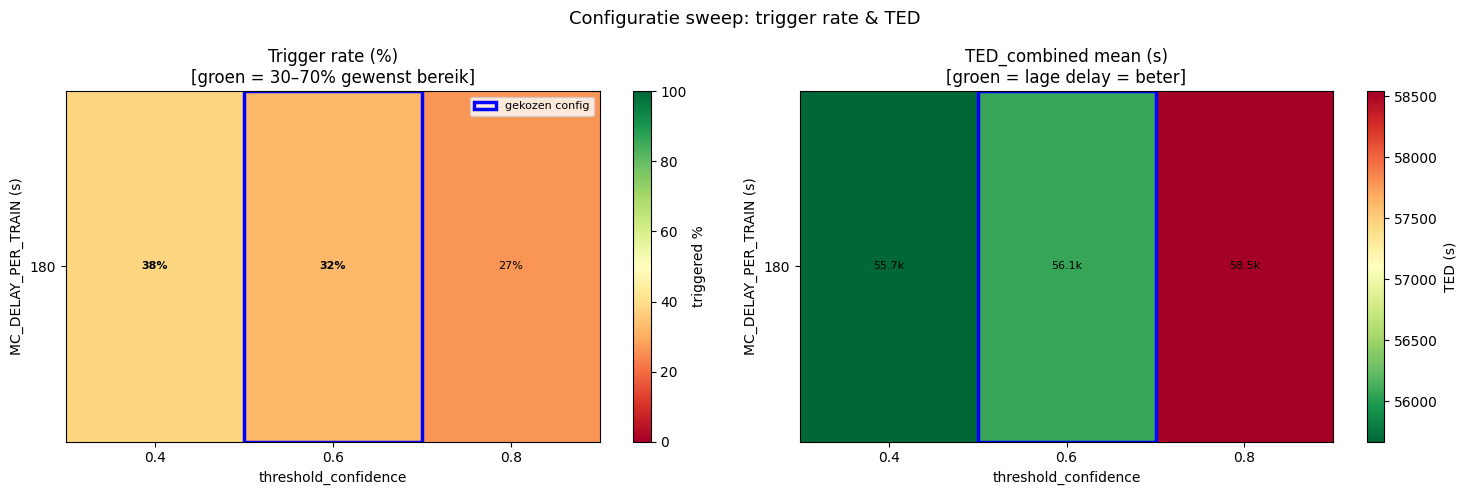

In [ ]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Configuratie sweep: trigger rate & TED", fontsize=13)

# ── Links: heatmap trigger rate (%) ──────────────────────────────────────────
ax = axes[0]
pivot_tr = conf_agg.pivot(
    index="mc_delay_per_train",
    columns="threshold_confidence",
    values="triggered_mean",
)

# Kleurschaal: groen in gewenst bereik (30-70%), rood buiten
cmap = plt.cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=50, vmax=100)

im = ax.imshow(
    pivot_tr.values,
    aspect="auto",
    cmap=cmap,
    norm=norm,
    origin="lower",
)
ax.set_xticks(range(len(pivot_tr.columns)))
ax.set_xticklabels([f"{c:.1f}" for c in pivot_tr.columns])
ax.set_yticks(range(len(pivot_tr.index)))
ax.set_yticklabels(pivot_tr.index)
ax.set_xlabel("threshold_confidence")
ax.set_ylabel("MC_DELAY_PER_TRAIN (s)")
ax.set_title("Trigger rate (%)\n[groen = 30–70% gewenst bereik]")

# Annoteer cellen met waarde
for i in range(len(pivot_tr.index)):
    for j in range(len(pivot_tr.columns)):
        val = pivot_tr.values[i, j]
        if not np.isnan(val):
            in_range = 30 <= val <= 70
            ax.text(j, i, f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=8,
                    fontweight="bold" if in_range else "normal",
                    color="black")

plt.colorbar(im, ax=ax, label="triggered %")

# Markeer gekozen configuratie als die in het grid zit
try:
    chosen_mc_idx   = list(pivot_tr.index).index(CHOSEN_MC)
    chosen_conf_idx = list(pivot_tr.columns).index(SIM_PARAMS["threshold_confidence"])
    rect = plt.Rectangle(
        (chosen_conf_idx - 0.5, chosen_mc_idx - 0.5), 1, 1,
        fill=False, edgecolor="blue", linewidth=2.5, label="gekozen config"
    )
    ax.add_patch(rect)
    ax.legend(fontsize=8, loc="upper right")
except ValueError:
    pass  # gekozen waarden niet in dit grid

# ── Rechts: heatmap TED_combined ─────────────────────────────────────────────
ax2 = axes[1]
pivot_ted_h = conf_agg.pivot(
    index="mc_delay_per_train",
    columns="threshold_confidence",
    values="TED_mean",
)

im2 = ax2.imshow(
    pivot_ted_h.values,
    aspect="auto",
    cmap="RdYlGn_r",   # lager TED = beter = groener
    origin="lower",
)
ax2.set_xticks(range(len(pivot_ted_h.columns)))
ax2.set_xticklabels([f"{c:.1f}" for c in pivot_ted_h.columns])
ax2.set_yticks(range(len(pivot_ted_h.index)))
ax2.set_yticklabels(pivot_ted_h.index)
ax2.set_xlabel("threshold_confidence")
ax2.set_ylabel("MC_DELAY_PER_TRAIN (s)")
ax2.set_title("TED_combined mean (s)\n[groen = lage delay = beter]")

for i in range(len(pivot_ted_h.index)):
    for j in range(len(pivot_ted_h.columns)):
        val = pivot_ted_h.values[i, j]
        if not np.isnan(val):
            ax2.text(j, i, f"{val/1000:.1f}k",
                     ha="center", va="center", fontsize=8, color="black")

plt.colorbar(im2, ax=ax2, label="TED (s)")

try:
    chosen_mc_idx   = list(pivot_ted_h.index).index(CHOSEN_MC)
    chosen_conf_idx = list(pivot_ted_h.columns).index(SIM_PARAMS["threshold_confidence"])
    rect2 = plt.Rectangle(
        (chosen_conf_idx - 0.5, chosen_mc_idx - 0.5), 1, 1,
        fill=False, edgecolor="blue", linewidth=2.5
    )
    ax2.add_patch(rect2)
except ValueError:
    pass

plt.tight_layout()
plt.show()

In [ ]:
# ── Samenvatting: welke configuraties zitten in het gewenste trigger-bereik? ──
TARGET_MIN = 30.0  # % van MC-evaluaties die leiden tot reschedule
TARGET_MAX = 70.0  # %

in_range = conf_agg[
    (conf_agg["triggered_mean"] >= TARGET_MIN) &
    (conf_agg["triggered_mean"] <= TARGET_MAX)
].sort_values("TED_mean")

out_range_low  = conf_agg[conf_agg["triggered_mean"] < TARGET_MIN].sort_values("triggered_mean")
out_range_high = conf_agg[conf_agg["triggered_mean"] > TARGET_MAX].sort_values("triggered_mean", ascending=False)

print(f"{'='*60}")
print(f"Configuraties in gewenst bereik ({TARGET_MIN:.0f}–{TARGET_MAX:.0f}% trigger rate):")
print(f"{'='*60}")
if in_range.empty:
    print("  ⚠️  Geen enkele configuratie in dit bereik gevonden.")
else:
    cols = ["mc_delay_per_train", "threshold_confidence",
            "triggered_mean", "triggered_std", "TED_mean", "n_rescheduled_mean"]
    print(in_range[cols].rename(columns={
        "mc_delay_per_train":   "MC (s)",
        "threshold_confidence": "conf",
        "triggered_mean":       "trig_mean%",
        "triggered_std":        "trig_std%",
        "TED_mean":             "TED_mean(s)",
        "n_rescheduled_mean":   "n_resc",
    }).to_string(index=False))

print()
print(f"Configuraties onder bereik (< {TARGET_MIN:.0f}%): {len(out_range_low)}")
print(f"Configuraties boven bereik (> {TARGET_MAX:.0f}%): {len(out_range_high)}")

print()
print("── Beste configuratie in bereik (laagste TED) ──")
if not in_range.empty:
    best = in_range.iloc[0]
    print(f"  MC_DELAY_PER_TRAIN   = {best['mc_delay_per_train']}s")
    print(f"  threshold_confidence = {best['threshold_confidence']}")
    print(f"  trigger rate mean    = {best['triggered_mean']:.1f}% (±{best['triggered_std']:.1f}%)")
    print(f"  n_evaluated mean     = {best['n_evaluated_mean']:.1f}")
    print(f"  TED_combined mean    = {best['TED_mean']:.0f}s")
    print(f"  n_rescheduled mean   = {best['n_rescheduled_mean']:.1f}")


Configuraties in gewenst bereik (30–70% trigger rate):
 MC (s)  conf  trig_mean%  trig_std%  TED_mean(s)  n_resc
    180   0.4       38.25       1.06     55668.60  270.10
    180   0.6       32.09       0.95     56061.94  242.25

Configuraties onder bereik (< 30%): 1
Configuraties boven bereik (> 70%): 0

── Beste configuratie in bereik (laagste TED) ──
  MC_DELAY_PER_TRAIN   = 180.0s
  threshold_confidence = 0.4
  trigger rate mean    = 38.2% (±1.1%)
  n_evaluated mean     = 706.4
  TED_combined mean    = 55669s
  n_rescheduled mean   = 270.1


In [ ]:
# Optioneel: sla sweep data op
conf_raw.to_csv("mc_conf_sweep_raw.csv", index=False)
conf_agg.to_csv("mc_conf_sweep_agg.csv", index=False)
print("Sweep data opgeslagen: mc_conf_sweep_raw.csv, mc_conf_sweep_agg.csv")

Sweep data opgeslagen: mc_conf_sweep_raw.csv, mc_conf_sweep_agg.csv


## Conclusie

Kijk naar de rij waar:
- `Δreschedule%` significant daalt (solver bespaart moeite)
- `ΔTED%` nog acceptabel is (delay stijgt weinig)

De waarde net **vóór** de grote TED-sprong is de aanbevolen `MC_DELAY_PER_TRAIN`.

Stel de waarde in `config/settings.py` in:
```python
MC_DELAY_PER_TRAIN = <gekozen waarde>
```

In [ ]:
# Optioneel: sla ruwe data op voor latere analyse
raw.to_csv("mc_threshold_raw.csv", index=False)
agg.to_csv("mc_threshold_agg.csv", index=False)
print("Data opgeslagen: mc_threshold_raw.csv, mc_threshold_agg.csv")

Data opgeslagen: mc_threshold_raw.csv, mc_threshold_agg.csv
